# 07. Balance persistence and sign transitions

Quantify how often each subsector records a positive or negative balance, how long those runs last, and what the empirical one-year sign transition frequencies are.

**Reads**

- `outputs/tables/persistence_summary.csv`
- `outputs/tables/persistence_by_regime.csv`
- `outputs/tables/transition_probabilities.csv`
- `data/processed/fiscal_balances_1977_2025.csv`

**Writes**

- Nothing. All three summaries are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 8

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Sign frequencies and run lengths

Counts are taken over the whole 1977-2025 panel. Longest runs are measured in
consecutive years with the same sign.

In [2]:
persistence = pd.read_csv(TABLES / 'persistence_summary.csv')
display(persistence.round(3))

,sector,n_years,positive_years,negative_years,mean_balance_pct_gdp,median_balance_pct_gdp,longest_positive_run,longest_negative_run
0,general_government,49,4,45,-4.915,-5.028,3,42
1,central_government,49,0,49,-5.381,-5.396,0,49
2,regional_local_government,49,18,31,-0.157,-0.124,8,12
3,social_security_funds,49,43,6,0.623,0.495,24,2


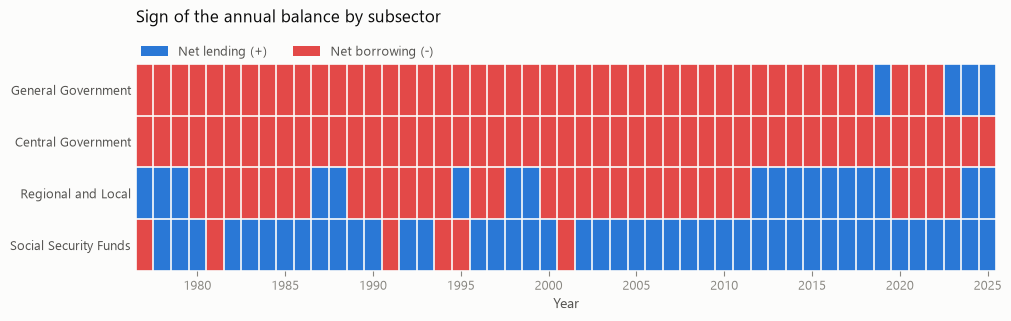

In [3]:
figure = figures.balance_sign_states(pd.read_csv(PROCESSED / 'fiscal_balances_1977_2025.csv'))

## 2. The pooled means describe neither regime

The magnitudes above average across the 1995 splice. The two regimes differ enough
that the pooled figure is not a good description of either one: it lands between
them and corresponds to no observed period.

Sign counts are far more robust to pooling, because a sign does not depend on the
level convention of the vintage. Both are shown per regime below so they are read
on one basis.

Runs are deliberately not recomputed per regime. A run is a property of the
uninterrupted series, and truncating it at a window boundary would report the
length of the window rather than the length of the run.

In [4]:
regime_persistence = pd.read_csv(TABLES / 'persistence_by_regime.csv')
display(regime_persistence.round(3))

,regime,sector,first_year,last_year,n_years,positive_years,negative_years,mean_balance_pct_gdp,median_balance_pct_gdp,min_balance_pct_gdp,max_balance_pct_gdp
0,1977-1994_historical,general_government,1977,1994,18,0,18,-6.429,-6.033,-12.463,-2.129
1,1977-1994_historical,central_government,1977,1994,18,0,18,-6.614,-6.312,-11.478,-2.659
2,1977-1994_historical,regional_local_government,1977,1994,18,5,13,-0.275,-0.190,-0.970,0.334
3,1977-1994_historical,social_security_funds,1977,1994,18,14,4,0.460,0.474,-0.379,1.362
4,1995-2025_modern,general_government,1995,2025,31,4,27,-4.036,-4.167,-11.418,1.121
5,1995-2025_modern,central_government,1995,2025,31,0,31,-4.666,-4.327,-11.008,-0.905
6,1995-2025_modern,regional_local_government,1995,2025,31,13,18,-0.088,-0.103,-0.858,0.495
7,1995-2025_modern,social_security_funds,1995,2025,31,29,2,0.718,0.610,-0.496,2.303


In [5]:
comparison = (
    regime_persistence.pivot(index='sector', columns='regime', values='mean_balance_pct_gdp')
    .join(persistence.set_index('sector')['mean_balance_pct_gdp'].rename('pooled'))
)
display(comparison.round(3))

,1977-1994_historical,1995-2025_modern,pooled
sector,,,
central_government,-6.614,-4.666,-5.381
general_government,-6.429,-4.036,-4.915
regional_local_government,-0.275,-0.088,-0.157
social_security_funds,0.460,0.718,0.623


## 3. One-year sign transitions

Each row of the persisted table is a `state -> next_state` frequency. Pivoting
gives one transition matrix per subsector, where each row sums to one.

In [6]:
transitions = pd.read_csv(TABLES / 'transition_probabilities.csv')
matrix = transitions.pivot_table(
    index=['sector', 'state'],
    columns='next_state',
    values='probability',
    fill_value=0.0,
)
display(matrix.round(3))
display(transitions.sort_values(['sector', 'state', 'next_state']).round(3))

next_state                          negative  positive
sector                    state                       
central_government        negative     1.000     0.000
general_government        negative     0.956     0.044
                          positive     0.333     0.667
regional_local_government negative     0.839     0.161
                          positive     0.294     0.706
social_security_funds     negative     0.167     0.833
                          positive     0.095     0.905

,sector,state,next_state,n,probability
4,central_government,negative,negative,48,1.000
0,general_government,negative,negative,43,0.956
1,general_government,negative,positive,2,0.044
2,general_government,positive,negative,1,0.333
3,general_government,positive,positive,2,0.667
5,regional_local_government,negative,negative,26,0.839
6,regional_local_government,negative,positive,5,0.161
7,regional_local_government,positive,negative,5,0.294
8,regional_local_government,positive,positive,12,0.706
9,social_security_funds,negative,negative,1,0.167


## Interpretation limits

1. These are **empirical frequencies over 48 transitions**, not a fitted Markov
   model. No standard errors or stationarity tests are claimed.
2. A state that never occurs in the sample has **no estimated row**, which is
   why some matrices are smaller than three by three.
3. Sign persistence describes the **recorded series**. It is not a forecast and
   carries no implication about future balances.
4. Runs that span 1995 also span the **statistical splice**.
5. **Pooled magnitudes are reported for completeness only.** The regime split is
   the form in which means and medians should be read.

---

[Previous: 06. Year-to-year balance attribution](06_year_to_year_attribution.ipynb) | [Next: 08. Structural mean shifts](08_structural_breaks.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```